# Notebook 03 – Community Detection

Louvain vs. Label Propagation — NMI/ARI vs. ground truth, comparison bar chart.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from graph_utils import load_graph
from community_detection import run_louvain, run_label_propagation, evaluate

os.makedirs(os.path.join('..', 'figures'), exist_ok=True)

EDGE_FILE = os.path.join('..', 'data', 'com-dblp.ungraph.txt')
COMM_FILE = os.path.join('..', 'data', 'com-dblp.top5000.cmty.txt')
G, ground_truth = load_graph(EDGE_FILE, COMM_FILE)
print(f'Graph: {G.number_of_nodes():,} nodes | Ground-truth communities: {len(ground_truth)}')

Graph: 317,080 nodes | Ground-truth communities: 5000


## 1. Louvain

In [2]:
print('Running Louvain...')
louvain_partition = run_louvain(G, seed=42)
louvain_metrics = evaluate(louvain_partition, ground_truth, G)
print(f'Louvain   |  Communities: {louvain_metrics["num_communities"]:,}')
print(f'          |  NMI: {louvain_metrics["nmi"]:.4f}   ARI: {louvain_metrics["ari"]:.4f}')

Running Louvain...
Louvain   |  Communities: 240
          |  NMI: 0.5281   ARI: 0.1180


## 2. Label Propagation

In [3]:
print('Running Label Propagation...')
lp_partition = run_label_propagation(G, seed=42)
lp_metrics = evaluate(lp_partition, ground_truth, G)
print(f'Label Prop|  Communities: {lp_metrics["num_communities"]:,}')
print(f'          |  NMI: {lp_metrics["nmi"]:.4f}   ARI: {lp_metrics["ari"]:.4f}')

Running Label Propagation...
Label Prop|  Communities: 43,190
          |  NMI: 0.7334   ARI: 0.0091


## 3. Comparison Table

In [4]:
results = {
    'Method': ['Louvain', 'Label Propagation'],
    '# Communities': [louvain_metrics['num_communities'], lp_metrics['num_communities']],
    'NMI': [louvain_metrics['nmi'], lp_metrics['nmi']],
    'ARI': [louvain_metrics['ari'], lp_metrics['ari']],
}
df = pd.DataFrame(results).set_index('Method')
print(df.to_string())

                   # Communities       NMI       ARI
Method                                              
Louvain                      240  0.528094  0.117965
Label Propagation          43190  0.733406  0.009096


## 4. Comparison Bar Chart

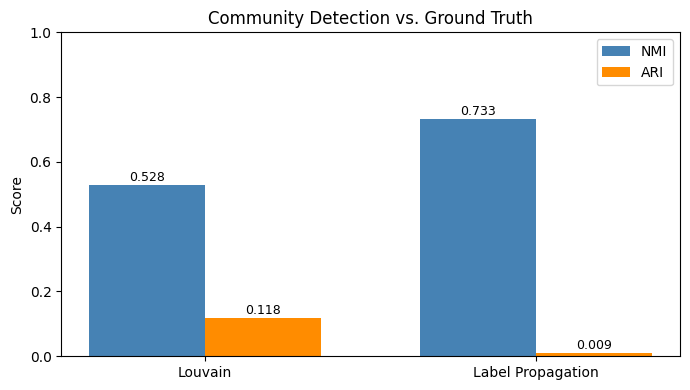

In [5]:
methods = ['Louvain', 'Label Propagation']
nmi_scores = [louvain_metrics['nmi'], lp_metrics['nmi']]
ari_scores = [louvain_metrics['ari'], lp_metrics['ari']]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width/2, nmi_scores, width, label='NMI', color='steelblue')
bars2 = ax.bar(x + width/2, ari_scores, width, label='ARI', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Community Detection vs. Ground Truth')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1)
ax.legend()

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'community_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Community Size Distributions

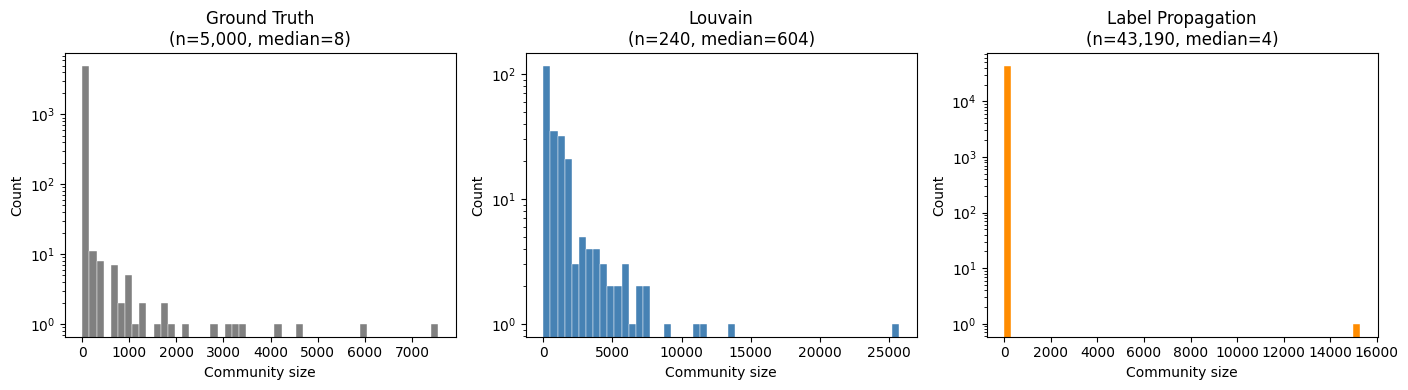

In [7]:
from collections import Counter

def partition_sizes(partition):
    comm_members = {}
    for node, cid in partition.items():
        comm_members.setdefault(cid, 0)
        comm_members[cid] += 1
    return list(comm_members.values())

louvain_sizes = partition_sizes(louvain_partition)
lp_sizes = partition_sizes(lp_partition)
gt_sizes = [len(c) for c in ground_truth]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, sizes, title, color in zip(axes,
    [gt_sizes, louvain_sizes, lp_sizes],
    ['Ground Truth', 'Louvain', 'Label Propagation'],
    ['gray', 'steelblue', 'darkorange']):
    ax.hist(sizes, bins=50, color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{title}\n(n={len(sizes):,}, median={int(np.median(sizes))})')
    ax.set_xlabel('Community size')
    ax.set_ylabel('Count')
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join('..', 'figures', 'community_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()